# Induced-EQ Forecasting Analysis

Modified from *Using Deep Learning for Flexible and Scalable Earthquake Forecasting*.
Reference: [Zenodo](https://zenodo.org/records/8161777)

## 1) Setup

In [1]:
import os
import sys
import functools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.catalogs as catalogs
import src.utils.catalog_tests as catalog_tests
from src.models.tpp import etas, recurrent
from src.train.config_setup import load_and_prepare_model
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.utils import set_seed
from src.utils.visualization import visualize_sequence, visualize_trajectories, plot_intensity

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Configuration

In [ ]:
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints' / 'etas_20260325-103006'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'best_model_1.pth'

# Optional: replace current background model with another checkpoint's background model.
USE_ALT_BG_MODEL = False
ALT_BG_CHECKPOINT_PATH = PROJECT_ROOT / 'checkpoints' / 'etas_20251221-224107' / 'best_model_1.pth'

USE_TORCH_COMPILE = True
MODEL_MM = 6.5  # set to None to skip overriding model.M_m

print(f'CHECKPOINT_PATH: {CHECKPOINT_PATH}')

CHECKPOINT_PATH: /root/autodl-tmp/em_eqf/checkpoints/etas_20260325-103006/best_model_1.pth


## 3) Load Model and Catalog

In [3]:
def unwrap_model(m):
    return m._orig_mod if hasattr(m, '_orig_mod') else m


model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)

if USE_ALT_BG_MODEL:
    alt_model, _ = load_and_prepare_model(
        checkpoint_path=ALT_BG_CHECKPOINT_PATH,
        device=DEVICE,
        compile=False,
    )
    if getattr(alt_model, 'bg_model', None) is not None:
        model.bg_model = alt_model.bg_model
    del alt_model

if MODEL_MM is not None and hasattr(model, 'M_m'):
    model.M_m = torch.tensor(float(MODEL_MM), device=DEVICE)

if getattr(model, 'bg_model', None) is not None:
    print(f'background scale: {model.bg_model._scale}')

if hasattr(model, 'print_params'):
    model.print_params()

background scale: 977.5848388671875
ETAS model parameters:
  p = 1.6322747068065473
  c = 0.003080982031925357
  mu = 0.0
  k = 0.010383415203164626
  K = 0.6357300395841761
  alpha = 0.3099965322362962
  alpha_e = 0.7137933940071438
  b = 0.8843895196914673
  M_c = -0.4000000059604645
  M_m = 6.5


Using catalog registry name: CB_HAB1a-Standard
Model: etas | Dataset: CB_HAB1a
train end index: 32.72402777777778
val end index: 39.73631944444445


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

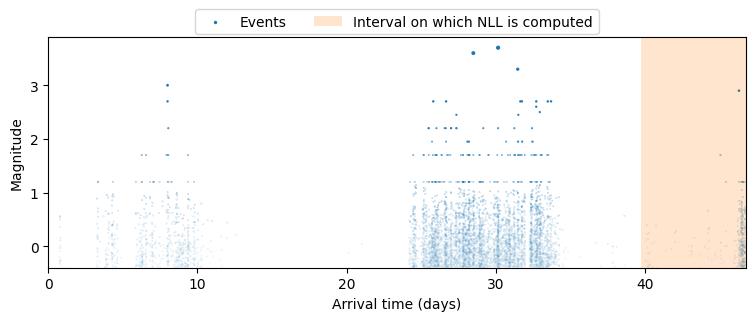

In [15]:
catalog_cfg = getattr(args, 'catalog_cfg', {})
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    args.dataset,
    base_dir=PROJECT_ROOT / 'data' / args.dataset,
    catalog_cfg=catalog_cfg,
)
print(f'Using catalog registry name: {registry_name}')

metadata = catalog_ds.metadata
start_ts = pd.to_datetime(metadata['start_ts'])
val_start_ts = pd.to_datetime(metadata['val_start_ts'])
test_start_ts = pd.to_datetime(metadata['test_start_ts'])
freq_td = pd.to_timedelta(metadata['freq'])

print(f'Model: {args.model} | Dataset: {args.dataset}')
print(f'train end index: {(val_start_ts - start_ts) / freq_td}')
print(f'val end index: {(test_start_ts - start_ts) / freq_td}')

train_seq = catalog_ds.train[0]
val_seq = catalog_ds.val[0]
test_seq = catalog_ds.test[0]

visualize_sequence(test_seq, show_nll=True)

## 4) Batch and Intensity Diagnostics

NLL(train), NLL(test): tensor([-5.3050], device='cuda:0', grad_fn=<DivBackward0>) tensor([-4.8243], device='cuda:0', grad_fn=<DivBackward0>)


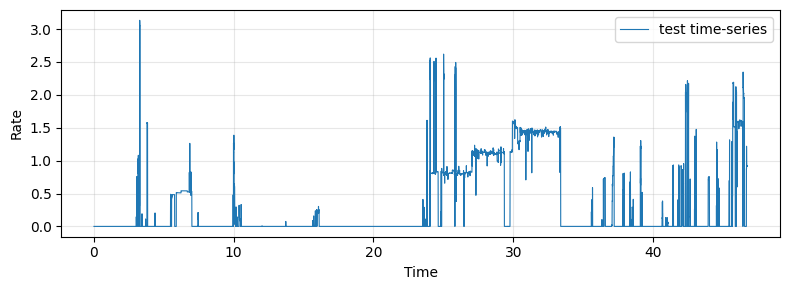

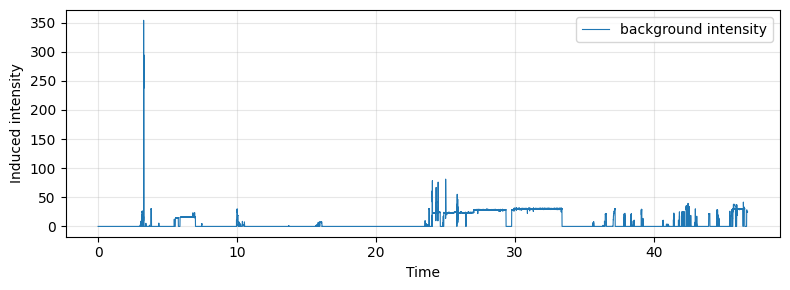

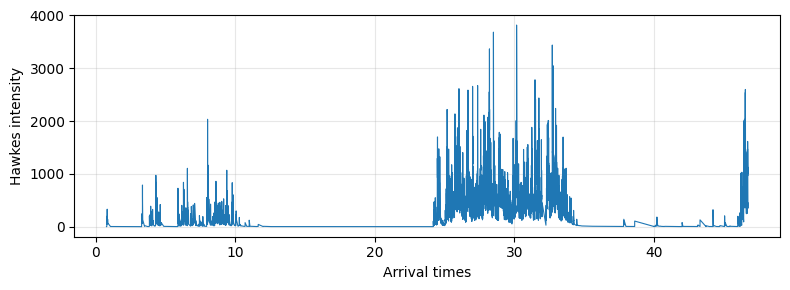

In [5]:
def sequence_to_batch(seq, device):
    batch = src.data.Batch.from_list([seq])
    return batch.to(device)


train_batch = sequence_to_batch(train_seq, DEVICE)
val_batch = sequence_to_batch(val_seq, DEVICE)
test_batch = sequence_to_batch(test_seq, DEVICE)

if hasattr(model, 'nll_loss'):
    print('NLL(train), NLL(test):', model.nll_loss(train_batch), model.nll_loss(test_batch))

batch = test_batch
plt.figure(figsize=(8, 3))
plt.plot(
    batch.time_series_times.squeeze().detach().cpu().numpy(),
    batch.time_series.squeeze().detach().cpu().numpy(),
    linewidth=0.8,
    label='test time-series',
)
plt.xlabel('Time')
plt.ylabel('Rate')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

if getattr(model, 'bg_model', None) is not None:
    f_intensity_trajectory = model.bg_model.intensity_trajectory(batch)
    plt.figure(figsize=(8, 3))
    plt.plot(
        batch.time_series_times.squeeze().detach().cpu().numpy(),
        f_intensity_trajectory.squeeze().detach().cpu().numpy(),
        linewidth=0.8,
        label='background intensity',
    )
    plt.xlabel('Time')
    plt.ylabel('Induced intensity')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / 'induced_intensity.png')
    plt.show()

core_model = unwrap_model(model)
if isinstance(core_model, recurrent.RecurrentTPP):
    context = model.get_context(batch)
    inter_time_dist = model.get_inter_time_dist(context)
    log_h = inter_time_dist.log_hazard(batch.inter_times.clamp_min(1e-10))
    h_intensity = torch.exp(log_h)
    h_intensity = torch.where(h_intensity > 500000, torch.tensor(0.0, device=h_intensity.device), h_intensity)

    window = 20
    arrival_times_np = batch.arrival_times.detach().cpu().numpy().ravel()
    raw_np = h_intensity.detach().cpu().numpy().ravel()
    smoothed = np.convolve(raw_np, np.ones(window) / window, mode='same')

    plt.figure(figsize=(8, 3))
    plt.plot(arrival_times_np, smoothed, linewidth=0.8, color='tab:red', label='smoothed history intensity')
    plt.xlabel('Arrival times')
    plt.ylabel('History intensity')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('count(h_intensity > 1000):', int((h_intensity > 1000).sum().item()))
elif isinstance(core_model, etas.ETAS):
    h_intensity = model.h_intensity(batch)
    plt.figure(figsize=(8, 3))
    plt.plot(
        batch.arrival_times.reshape(-1)[:-1].detach().cpu().numpy(),
        h_intensity.reshape(-1).detach().cpu().numpy(),
        linewidth=0.8,
        color='tab:blue',
    )
    plt.xlabel('Arrival times')
    plt.ylabel('Hawkes intensity')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / 'hawkes_intensity.png')
    plt.show()

## 5) Single-Window Forecast

In [16]:
# Single forecast window settings
T_FORECAST = 24
FORECAST_DURATION = 5
NUM_SAMPLES = 1000
SAMPLES_PER_BATCH = 1000

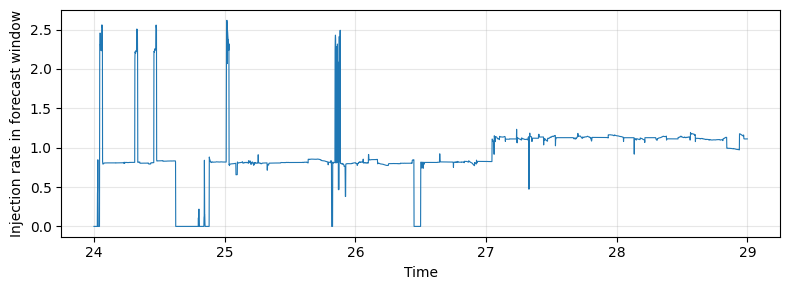

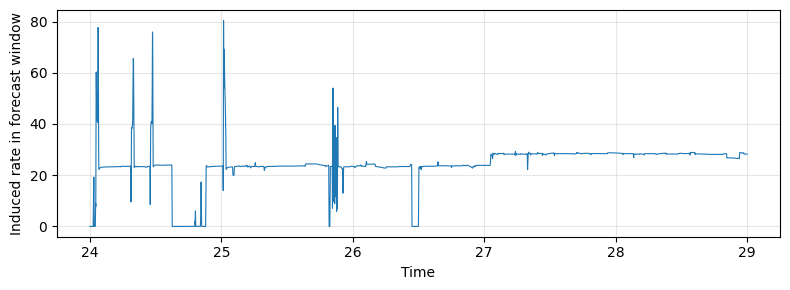

Background forecast count in [24, 29]: 120.6615982055664
Observed events in window: 2755


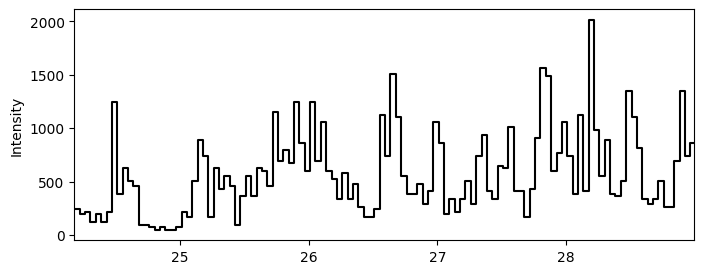

In [17]:
past_seq = test_seq.get_subsequence(0, T_FORECAST, reset_t_nll_to_end=True)
observed_seq = test_seq.get_subsequence(T_FORECAST, T_FORECAST + FORECAST_DURATION, reset_t_nll_to_end=True)

mask_future = (test_seq.time_series_times >= T_FORECAST) & (test_seq.time_series_times < T_FORECAST + FORECAST_DURATION)
future_time_series = test_seq.time_series[mask_future]
future_time_series_times = test_seq.time_series_times[mask_future]

plt.figure(figsize=(8, 3))
plt.plot(
    future_time_series_times.detach().cpu().numpy(),
    future_time_series.reshape(-1).detach().cpu().numpy(),
    linewidth=0.8,
    color='tab:blue',
)
plt.xlabel('Time')
plt.ylabel('Injection rate in forecast window')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if getattr(model, 'bg_model', None) is not None:
    model.bg_model.cache_batch(
        time_series=test_seq.time_series.unsqueeze(0),
        time_series_times=test_seq.time_series_times.unsqueeze(0),
    )
    times_all = test_seq.time_series_times
    window_mask = (times_all >= T_FORECAST) & (times_all < T_FORECAST + FORECAST_DURATION)
    f_intensity = model.bg_model.intensity(
        ts_batch=model.bg_model.ts_batch_cache,
        t_query=times_all[window_mask].unsqueeze(0),
    )
    plt.figure(figsize=(8, 3))
    plt.plot(times_all[window_mask], f_intensity.reshape(-1).detach().cpu().numpy(), linewidth=0.8, color='tab:blue')
    plt.xlabel('Time')
    plt.ylabel('Induced rate in forecast window')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    bg_count = model.bg_model.forecast_count(T_FORECAST, T_FORECAST + FORECAST_DURATION)
    print(f'Background forecast count in [{T_FORECAST}, {T_FORECAST + FORECAST_DURATION}]: {bg_count}')

plot_intensity(observed_seq, dt=1 / 24)
print('Observed events in window:', len(observed_seq))

  0%|          | 0/1000 [00:00<?, ?it/s]

/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 2 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Total forecasts: 1000
Forecasts containing zero inter_times: 7


(<Figure size 1500x450 with 3 Axes>,
 (<Axes: title={'center': 'Observed Sequence and Example Forecast Trajectories'}, xlabel='Days since 2003-11-06', ylabel='Magnitude'>,
  <Axes: title={'center': 'Forecast counts'}, xlabel='Frequency', ylabel='Event count in window'>,
  <Axes: ylabel='Cumulative count'>))

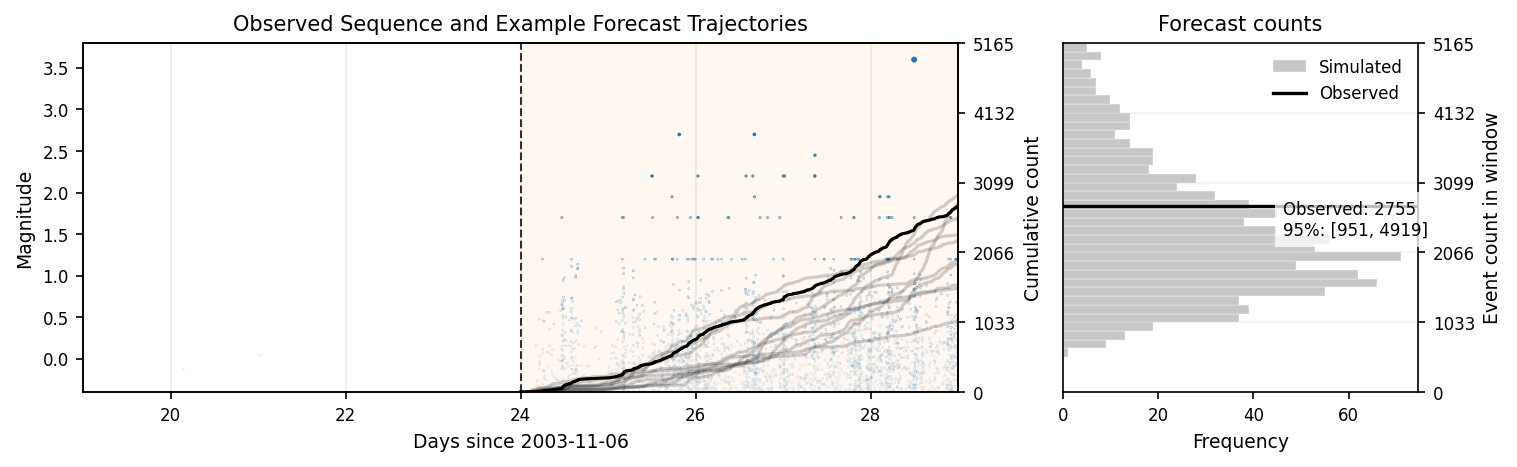

In [18]:
def generate_forecasts(model, past_seq, duration, num_samples, samples_per_batch, seed=3):
    return sample_tpp_forecasts(
        model,
        past_seq,
        duration=duration,
        num_samples=int(num_samples),
        samples_per_batch=samples_per_batch,
        seed=seed,
    )


past_seq_device = past_seq.to(DEVICE) if torch.cuda.is_available() else past_seq
all_forecasts = generate_forecasts(
    model=model,
    past_seq=past_seq_device,
    duration=FORECAST_DURATION,
    num_samples=NUM_SAMPLES,
    samples_per_batch=SAMPLES_PER_BATCH,
    seed=3,
)

zero_indices = []
for idx, fc in enumerate(all_forecasts):
    inter_times = torch.as_tensor(fc.inter_times).cpu()
    if (inter_times == 0).any():
        zero_indices.append(idx)

print('Total forecasts:', len(all_forecasts))
print('Forecasts containing zero inter_times:', len(zero_indices))
date_strs = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d') if hasattr(catalog_ds.metadata['start_ts'], 'strftime') else 'start'
visualize_trajectories(
    test_seq,
    all_forecasts,
    save_path=CHECKPOINT_DIR / 'all_forecasts.pdf',
    figsize=(10, 3),
    xlabel='Days since ' + date_strs,
    reset_t_nll_to_end=True,
)

## 6) RMSE, N-Test, and M-Test

RMSE: 1837.149841
Empty forecasts: 0
Forecast mag range (non-empty only): (7.411356617708853, -0.399999871847315)
Observed mag range: (3.700000047683716, -0.39966753125190735)


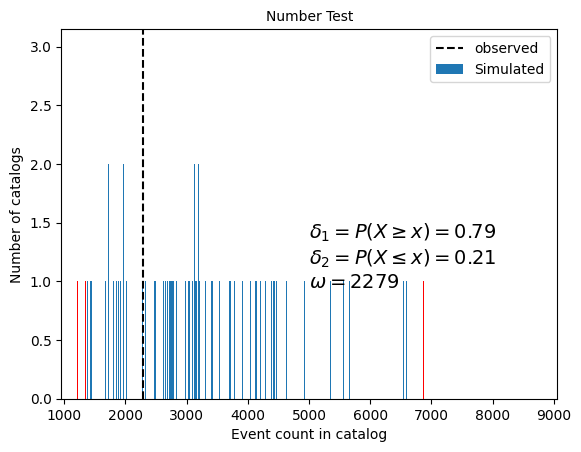

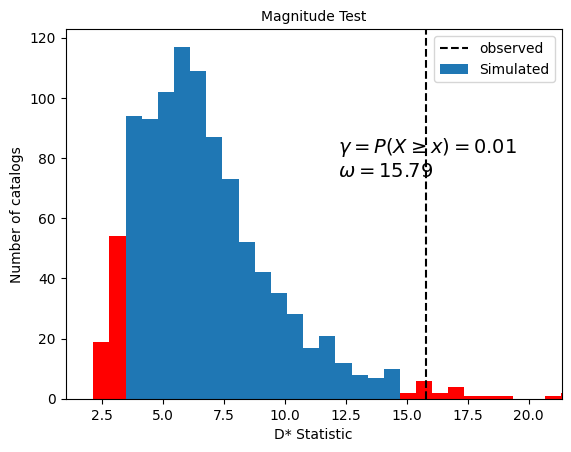

In [11]:
forecast_counts = np.array([len(fc) for fc in all_forecasts], dtype=float)
observed_count = len(observed_seq)
rmse = float(np.sqrt(np.mean((forecast_counts - observed_count) ** 2)))
print(f'RMSE: {rmse:.6f}')

number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=observed_count,
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
)
number_test_result.plot(plot_args={'figsize': (6.4, 4.8), 'tight_layout': False})
plt.savefig(CHECKPOINT_DIR / 'n_test.pdf')

non_empty_forecasts = [fc for fc in all_forecasts if len(fc) > 0]
empty_forecast_count = len(all_forecasts) - len(non_empty_forecasts)
print('Empty forecasts:', empty_forecast_count)

if non_empty_forecasts:
    mag_max = [fc.mag.max().item() for fc in non_empty_forecasts]
    mag_min = [fc.mag.min().item() for fc in non_empty_forecasts]
    print('Forecast mag range (non-empty only):', (max(mag_max), min(mag_min)))
else:
    print('Forecast mag range: no non-empty forecasts')

if len(observed_seq) > 0:
    print('Observed mag range:', (observed_seq.mag.max().item(), observed_seq.mag.min().item()))
else:
    print('Observed mag range: observed sequence is empty')

config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01,
}

if non_empty_forecasts:
    # quick check distribution API on one non-empty forecast
    _ = catalog_tests.compute_magnitude_distribution(non_empty_forecasts[0].mag.cpu().numpy(), **config_dict)

get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,
    debug=False,
)

magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
)
magnitude_test_result.plot(plot_args={'figsize': (6.4, 4.8), 'tight_layout': False})
plt.savefig(CHECKPOINT_DIR / 'm_test.pdf')

## 7) Sliding-Window Forecast Evaluation

In [12]:
# Sliding-window settings
SLIDING_DURATION = 12
SLIDING_STEP = 12
SLIDING_QUANTILES = (2.5, 97.5)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-ev

acceptance rate: 100.00%


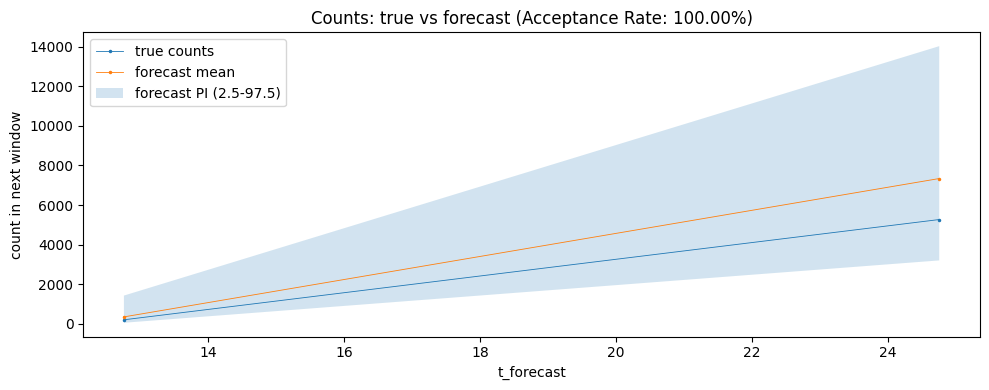

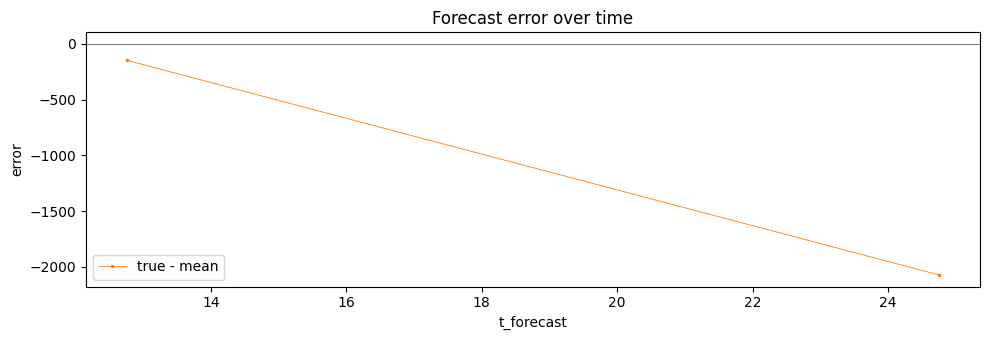

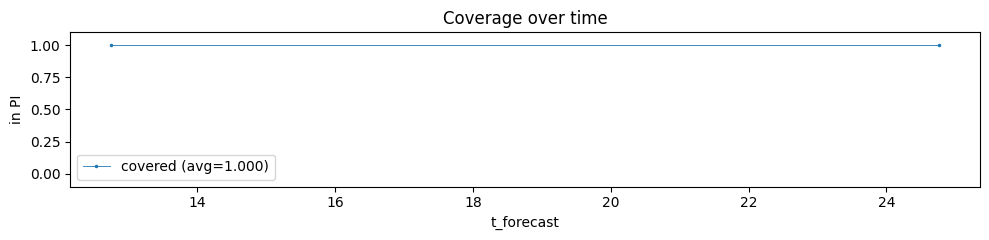

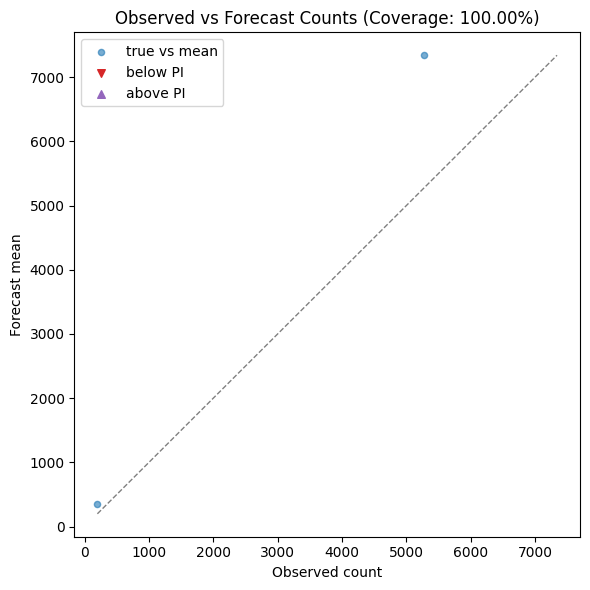

In [13]:
def run_sliding_window_forecast(
    model,
    test_seq,
    device,
    duration=12,
    slide_step=12,
    quantiles=(2.5, 97.5),
    samples_per_batch=1000,
):
    start = float(test_seq.arrival_times[0].item())
    end = float(test_seq.arrival_times[-1].item())

    t_forecast_list = np.arange(start + duration, end - duration, slide_step)

    counts_list = []
    q_list = []
    mean_list = []

    model.eval()

    for t_forecast in t_forecast_list:
        t_end = min(t_forecast + duration, end)

        past_seq = test_seq.get_subsequence(0, t_forecast, reset_t_nll_to_end=True).to(device)
        observed_seq = test_seq.get_subsequence(t_forecast, t_end, reset_t_nll_to_end=True).to(device)

        forecasts = model.sample(
            batch_size=samples_per_batch,
            duration=(t_end - t_forecast),
            past_seq=past_seq,
            return_sequences=True,
        )
        fc_counts = np.fromiter((len(fc) for fc in forecasts), dtype=np.int32)

        q = np.percentile(fc_counts, quantiles)
        mean = float(fc_counts.mean())

        q_list.append(q)
        mean_list.append(mean)
        counts_list.append(len(observed_seq))

    return np.array(t_forecast_list), np.array(counts_list), np.array(q_list), np.array(mean_list)


t_forecast_list, counts_list, q_list, mean_list = run_sliding_window_forecast(
    model=model,
    test_seq=test_seq,
    device=DEVICE,
    duration=SLIDING_DURATION,
    slide_step=SLIDING_STEP,
    quantiles=SLIDING_QUANTILES,
    samples_per_batch=SAMPLES_PER_BATCH,
)

if len(t_forecast_list) == 0:
    print('No sliding windows available with current duration/step settings.')
else:
    q_low, q_high = q_list[:, 0], q_list[:, 1]
    covered = (counts_list >= q_low) & (counts_list <= q_high)
    coverage = float(covered.mean())
    print(f'acceptance rate: {coverage:.2%}')

    plt.figure(figsize=(10, 4))
    plt.plot(t_forecast_list, counts_list, label='true counts', linewidth=0.6, marker='o', markersize=1.5)
    plt.plot(t_forecast_list, mean_list, label='forecast mean', linewidth=0.6, marker='o', markersize=1.5)
    plt.fill_between(t_forecast_list, q_low, q_high, alpha=0.2, label='forecast PI (2.5-97.5)')
    plt.xlabel('t_forecast')
    plt.ylabel('count in next window')
    plt.title(f'Counts: true vs forecast (Acceptance Rate: {coverage:.2%})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / 'forecast_counts_over_time.png')
    plt.show()

    err = counts_list - mean_list
    plt.figure(figsize=(10, 3.5))
    plt.plot(t_forecast_list, err, label='true - mean', linewidth=0.6, marker='o', markersize=1.5, color='tab:orange')
    plt.axhline(0, linewidth=0.8, color='gray')
    plt.xlabel('t_forecast')
    plt.ylabel('error')
    plt.title('Forecast error over time')
    plt.legend()
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / 'forecast_error_over_time.png')
    plt.show()

    plt.figure(figsize=(10, 2.5))
    plt.plot(t_forecast_list, covered.astype(int), label=f'covered (avg={coverage:.3f})', linewidth=0.6, marker='o', markersize=1.5)
    plt.ylim(-0.1, 1.1)
    plt.xlabel('t_forecast')
    plt.ylabel('in PI')
    plt.title('Coverage over time')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.scatter(counts_list, mean_list, color='tab:blue', alpha=0.6, s=20, label='true vs mean')

    out_of_lower = counts_list < q_low
    out_of_upper = counts_list > q_high

    plt.scatter(counts_list[out_of_lower], mean_list[out_of_lower], color='tab:red', marker='v', s=30, label='below PI')
    plt.scatter(counts_list[out_of_upper], mean_list[out_of_upper], color='tab:purple', marker='^', s=30, label='above PI')

    min_val = min(float(counts_list.min()), float(mean_list.min()))
    max_val = max(float(counts_list.max()), float(mean_list.max()))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', linewidth=1)

    plt.xlabel('Observed count')
    plt.ylabel('Forecast mean')
    plt.title(f'Observed vs Forecast Counts (Coverage: {coverage:.2%})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / 'obs_vs_forecast_scatter.png')
    plt.show()